<a href="https://www.kaggle.com/code/sonawanelalitsunil/job-descriptions-2025-ml-96-73?scriptVersionId=262612892" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from wordcloud import WordCloud
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/job-descriptions-2025-tech-and-non-tech-roles/job_dataset.json
/kaggle/input/job-descriptions-2025-tech-and-non-tech-roles/job_dataset.csv


## Job Descriptions 2025

## Description:
A comprehensive collection of job descriptions for both technical and non-technical roles in 2025. This resource outlines key responsibilities, required skills, and qualifications to help candidates understand role expectations and assist employers in defining clear hiring criteria.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/job-descriptions-2025-tech-and-non-tech-roles/job_dataset.csv")

In [3]:
df.head()

,JobID,Title,ExperienceLevel,YearsOfExperience,Skills,Responsibilities,Keywords
0,NET-F-001,.NET Developer,Fresher,0-1,C#; VB.NET basics; .NET Framework; .NET Core f...,Assist in coding and debugging applications; L...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...
1,NET-F-002,.NET Developer,Fresher,0-1,C#; .NET Framework basics; ASP.NET; Razor; HTM...,Write simple C# programs under guidance; Suppo...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...
2,NET-F-003,.NET Developer,Fresher,0-1,C#; VB.NET basics; .NET Core; ASP.NET MVC; HTM...,Contribute to development of small modules; As...,.NET; C#; ASP.NET MVC; SQL Server; Entity Fram...
3,NET-F-004,.NET Developer,Fresher,0-1,C#; .NET Framework; ASP.NET basics; SQL Server...,Support in software design documentation; Assi...,.NET; C#; SQL Server; Entity Framework; ASP.NET
4,NET-F-005,.NET Developer,Fresher,0-1,C#; ASP.NET; MVC; Entity Framework basics; SQL...,Learn to design and build ASP.NET applications...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...


In [4]:
df.tail()

,JobID,Title,ExperienceLevel,YearsOfExperience,Skills,Responsibilities,Keywords
1063,WEB-E-016,Web Developer,Experienced,5+,JavaScript; Angular; Node.js; Express.js; Djan...,Develop Angular front-end applications; Implem...,Angular; Node.js; Express.js; Django; SQL; Red...
1064,WEB-E-017,Web Developer,Experienced,4+,JavaScript; TypeScript; React; Node.js; Expres...,Develop and maintain full stack applications; ...,React; Node.js; Express.js; SQL; MongoDB; Dock...
1065,WEB-E-018,Web Developer,Experienced,5+,JavaScript; Vue.js; Node.js; Express.js; SQL; ...,Lead Vue.js front-end development; Integrate N...,Vue.js; Node.js; Express.js; SQL; Redis; Docke...
1066,WEB-E-019,Web Developer,Experienced,4+,JavaScript; React; Node.js; Express.js; MongoD...,Develop complex web applications; Integrate Re...,React; Node.js; Express.js; MongoDB; Docker; K...
1067,WEB-E-020,Web Developer,Experienced,5+,JavaScript; TypeScript; Angular; Node.js; Expr...,Lead Angular front-end development; Develop No...,Angular; Node.js; Express.js; SQL; Redis; Dock...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   JobID              1068 non-null   object
 1   Title              1067 non-null   object
 2   ExperienceLevel    1068 non-null   object
 3   YearsOfExperience  1068 non-null   object
 4   Skills             1068 non-null   object
 5   Responsibilities   1068 non-null   object
 6   Keywords           1068 non-null   object
dtypes: object(7)
memory usage: 58.5+ KB


In [6]:
df.describe()

,JobID,Title,ExperienceLevel,YearsOfExperience,Skills,Responsibilities,Keywords
count,1068,1067,1068,1068,1068,1068,1068
unique,1038,218,11,110,969,1047,678
top,5,.NET Developer,Experienced,0-1,Salesforce; HubSpot; Predictive Analytics; Lea...,Define and drive product strategy; Lead produc...,JavaScript; TypeScript; React; Node.js; Jest; ...
freq,3,20,476,247,6,3,15


In [7]:
df.isnull().sum()

JobID                0
Title                1
ExperienceLevel      0
YearsOfExperience    0
Skills               0
Responsibilities     0
Keywords             0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

JobID                object
Title                object
ExperienceLevel      object
YearsOfExperience    object
Skills               object
Responsibilities     object
Keywords             object
dtype: object

In [10]:
df.shape

(1068, 7)

In [11]:
df.columns

Index(['JobID', 'Title', 'ExperienceLevel', 'YearsOfExperience', 'Skills',
       'Responsibilities', 'Keywords'],
      dtype='object')

## Data visualizations

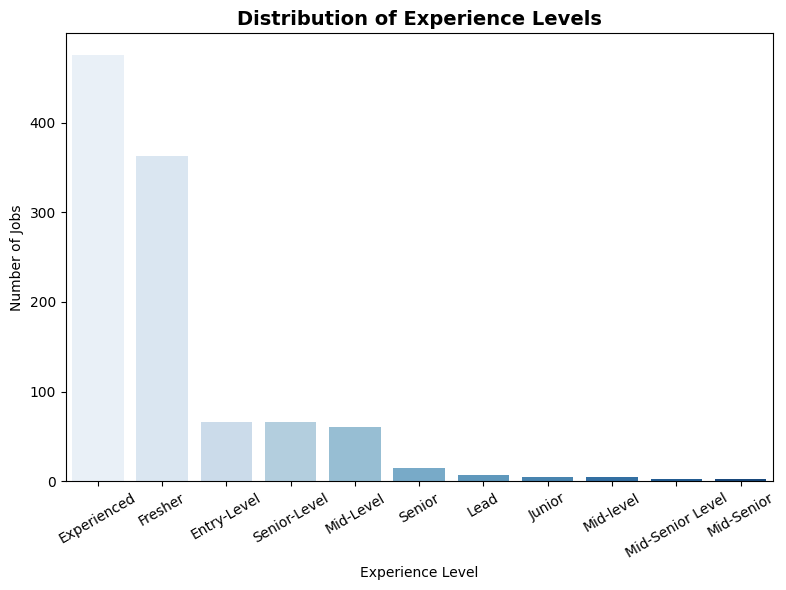

In [12]:
plt.figure(figsize=(8,6))
sns.countplot(x="ExperienceLevel", data=df, order=df["ExperienceLevel"].value_counts().index, palette="Blues")
plt.title("Distribution of Experience Levels", fontsize=14, fontweight="bold")
plt.xlabel("Experience Level")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

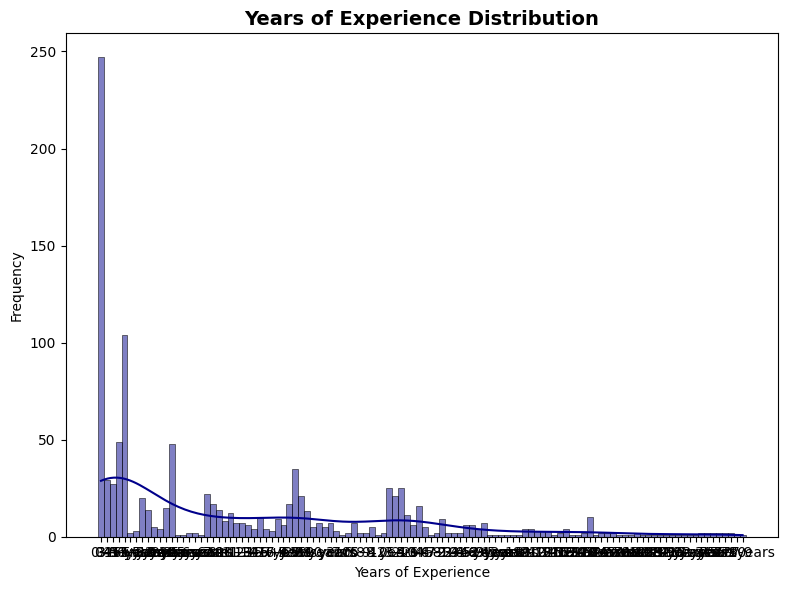

In [13]:
plt.figure(figsize=(8,6))
sns.histplot(df["YearsOfExperience"], bins=15, kde=True, color="darkblue")
plt.title("Years of Experience Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Years of Experience")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

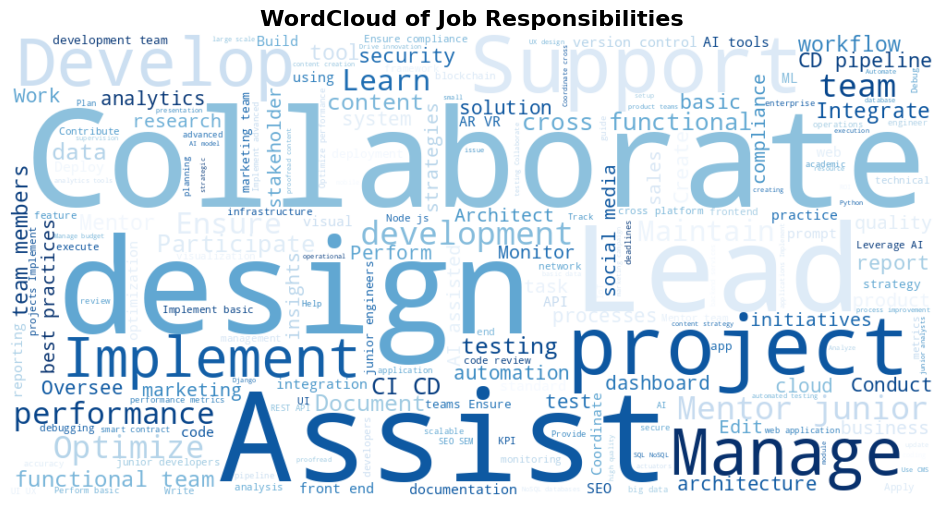

In [14]:
text_responsibilities = " ".join(df["Responsibilities"].dropna().astype(str))
wordcloud_resp = WordCloud(width=1000, height=500, background_color="white", colormap="Blues").generate(text_responsibilities)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_resp, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Job Responsibilities", fontsize=16, fontweight="bold")
plt.show()

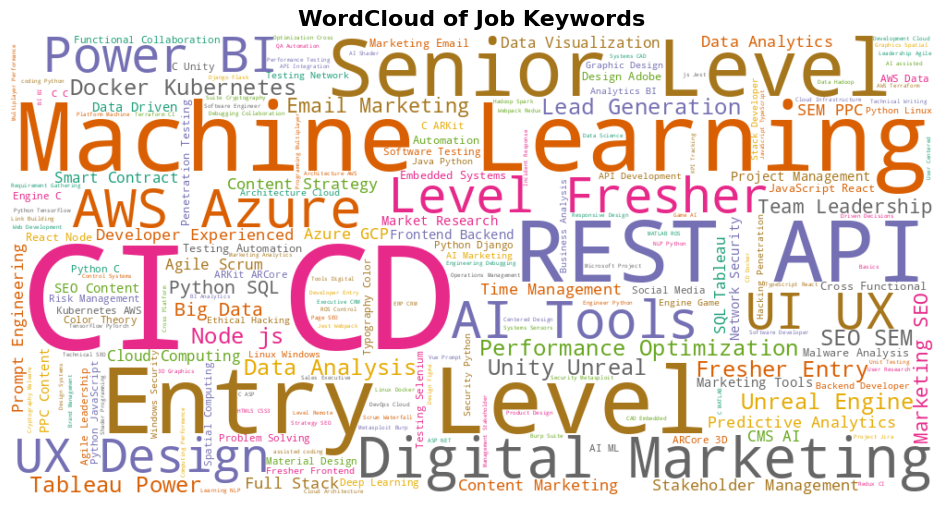

In [15]:
text_keywords = " ".join(df["Keywords"].dropna().astype(str))
wordcloud_keywords = WordCloud(width=1000, height=500, background_color="white", colormap="Dark2").generate(text_keywords)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_keywords, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Job Keywords", fontsize=16, fontweight="bold")
plt.show()

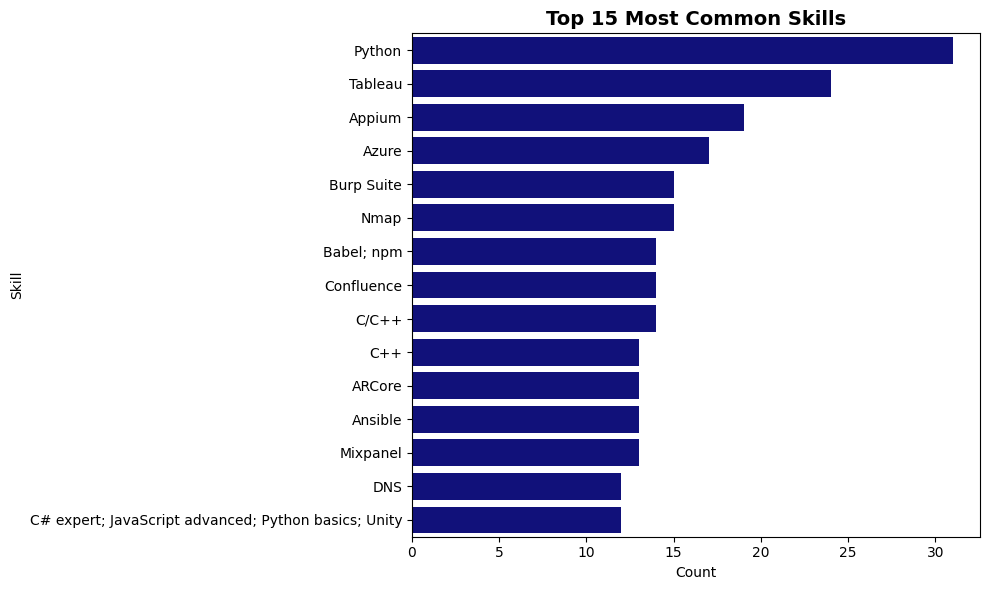

In [16]:
all_skills = df["Skills"].dropna().str.split(",").explode().str.strip()
top_skills = all_skills.value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_skills.values, y=top_skills.index, color="darkblue")
plt.title("Top 15 Most Common Skills", fontsize=14, fontweight="bold")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

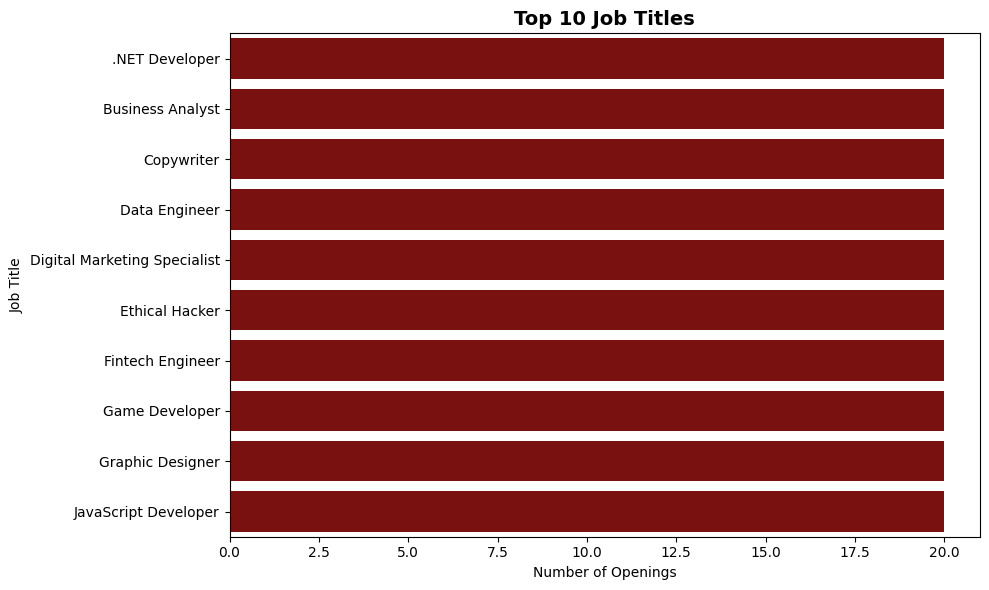

In [17]:
top_titles = df["Title"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_titles.values, y=top_titles.index, color="darkred")
plt.title("Top 10 Job Titles", fontsize=14, fontweight="bold")
plt.xlabel("Number of Openings")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()

## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [20]:
def clean_experience(val):
    if pd.isna(val):
        return 0
    val = str(val).lower().replace("yrs", "").replace("+", "").strip()
    if "-" in val:
        parts = val.split("-")
        try:
            return int((int(parts[0]) + int(parts[1])) / 2)
        except:
            return 0
    try:
        return int(val)
    except:
        return 0

df["YearsOfExperience"] = df["YearsOfExperience"].apply(clean_experience)

# Target variable
y = df["ExperienceLevel"]

# Encode Target
le = LabelEncoder()
y = le.fit_transform(y)

# Encode categorical 'Title'
df["Title"] = LabelEncoder().fit_transform(df["Title"].astype(str))

# Combine text columns
df["text_features"] = (
    df["Skills"].fillna("") + " " +
    df["Responsibilities"].fillna("") + " " +
    df["Keywords"].fillna("")
)

In [21]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=500)
X_text = tfidf.fit_transform(df["text_features"]).toarray()

# Final feature set = [Title + YearsOfExperience + TF-IDF]
X = np.hstack([df[["Title", "YearsOfExperience"]].values, X_text])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Naive Bayes": MultinomialNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [23]:
accuracy_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100  # percentage
    accuracy_results[name] = acc
    print(f"{name}: {acc:.2f}%")

Logistic Regression: 89.72%
Decision Tree: 92.06%
Random Forest: 96.73%
Gradient Boosting: 94.86%
Naive Bayes: 70.09%
SVM: 59.35%
KNN: 92.99%


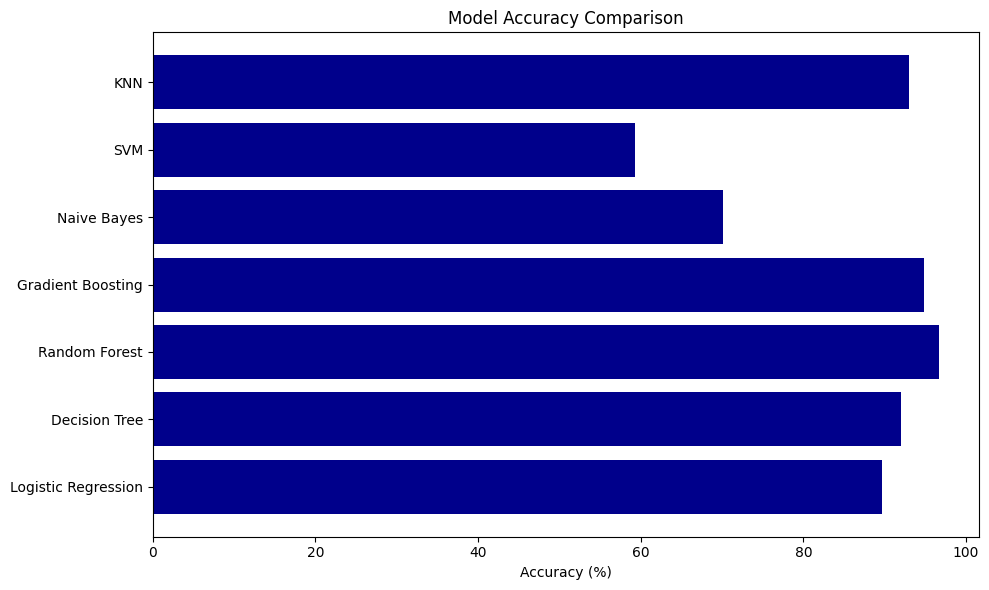

In [24]:
plt.figure(figsize=(10,6))
plt.barh(list(accuracy_results.keys()), list(accuracy_results.values()), color="darkblue")
plt.xlabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

## Thank you..pls upvote!!!!